### Importing Libraries

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('shopping_trends.csv')

### Data Cleaning

In [49]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [50]:
df.shape

(3900, 19)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [52]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Credit Card,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,696,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.749949,NaN,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716223,NaN,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


### Missing Values Check

In [53]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [54]:
missing_percentage = (df.isnull().sum()/len(df)*100)
missing_percentage.sort_values(ascending=False)

Customer ID                 0.0
Age                         0.0
Gender                      0.0
Item Purchased              0.0
Category                    0.0
Purchase Amount (USD)       0.0
Location                    0.0
Size                        0.0
Color                       0.0
Season                      0.0
Review Rating               0.0
Subscription Status         0.0
Payment Method              0.0
Shipping Type               0.0
Discount Applied            0.0
Promo Code Used             0.0
Previous Purchases          0.0
Preferred Payment Method    0.0
Frequency of Purchases      0.0
dtype: float64

### Duplicate Check

In [55]:
df.duplicated().sum()

np.int64(0)

### Unique Values

In [56]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

### Data Quality Check

In [57]:
# Numeric columns ki detailed summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,1950.500000,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,44.068462,15.207589,18.0,31.00,44.0,57.00,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.00,60.0,81.00,100.0
Review Rating,3900.0,3.749949,0.716223,2.5,3.10,3.7,4.40,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.00,25.0,38.00,50.0


In [58]:
# Customer ID uniqueness
df['Customer ID'].nunique()

3900

In [59]:
len(df)

3900

In [60]:
# Logical range checksprint("Age:", df["Age"].min(), "-", df["Age"].max())
print("Purchase Amount:", df["Purchase Amount (USD)"].min(), "-", df["Purchase Amount (USD)"].max())
print("Rating:", df["Review Rating"].min(), "-", df["Review Rating"].max())
print("Previous Purchases:", df["Previous Purchases"].min(), "-", df["Previous Purchases"].max())


Purchase Amount: 20 - 100
Rating: 2.5 - 5.0
Previous Purchases: 1 - 50


In [61]:
# Negative values check
numerical_col = df.select_dtypes(include="number").columns

for col in numerical_col:
    print(col,"negative values:",(df[col]<0).sum())

Customer ID negative values: 0
Age negative values: 0
Purchase Amount (USD) negative values: 0
Review Rating negative values: 0
Previous Purchases negative values: 0


In [62]:
# Unique categories
categories_col = df.select_dtypes(include = 'object').columns

for col in categories_col:
    print(f"\n {col}:")
    print(df[col].unique())



 Gender:
['Male' 'Female']

 Item Purchased:
['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']

 Category:
['Clothing' 'Footwear' 'Outerwear' 'Accessories']

 Location:
['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virginia' 'Georgia' 'Nebraska' 'Iowa' 'South Dakota' 'Minnesota'
 'Washington' 'Wisconsin' 'Michigan']

 Size:
['L' 'S' 'M' 'XL']

 Color:
['Gray' 'Maroon' 'Turquoise' 'White

In [63]:
# Leading/trailing spaces check
for col in categories_col:
     spaces = df[col].astype(str).str.strip().ne(df[col].astype(str)).sum()
     print(col, ":", spaces)


Gender : 0
Item Purchased : 0
Category : 0
Location : 0
Size : 0
Color : 0
Season : 0
Subscription Status : 0
Payment Method : 0
Shipping Type : 0
Discount Applied : 0
Promo Code Used : 0
Preferred Payment Method : 0
Frequency of Purchases : 0


In [64]:
# Text case consistency
for col in categories_col:
    print(f"\n{col}:")
    print("Unique values:", df[col].nunique())


Gender:
Unique values: 2

Item Purchased:
Unique values: 25

Category:
Unique values: 4

Location:
Unique values: 50

Size:
Unique values: 4

Color:
Unique values: 25

Season:
Unique values: 4

Subscription Status:
Unique values: 2

Payment Method:
Unique values: 6

Shipping Type:
Unique values: 6

Discount Applied:
Unique values: 2

Promo Code Used:
Unique values: 2

Preferred Payment Method:
Unique values: 6

Frequency of Purchases:
Unique values: 7


In [65]:
frequency_mapping = {
    "Fortnightly": "Bi-Weekly",
    "Every 3 Months": "Quarterly"
}

df["Frequency of Purchases"] = df["Frequency of Purchases"].replace(frequency_mapping)

In [66]:
df["Frequency of Purchases"].value_counts()

Frequency of Purchases
Quarterly    1147
Bi-Weekly    1089
Annually      572
Monthly       553
Weekly        539
Name: count, dtype: int64

In [67]:
# Discount vs Promo Code
pd.crosstab(
    df["Discount Applied"],
    df["Promo Code Used"]
)

Promo Code Used,No,Yes
Discount Applied,,
No,2223,0
Yes,0,1677


In [68]:
df.head(2)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Bi-Weekly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Bi-Weekly


In [69]:
# Payment Method vs Preferred Payment Method
pd.crosstab(
    df['Payment Method'],
    df['Preferred Payment Method']
)

Preferred Payment Method,Bank Transfer,Cash,Credit Card,Debit Card,PayPal,Venmo
Payment Method,,,,,,
Bank Transfer,103,107,123,104,101,94
Cash,97,120,116,91,116,108
Credit Card,119,122,96,124,126,109
Debit Card,103,105,118,87,106,114
PayPal,96,112,96,116,110,108
Venmo,94,104,122,114,118,101


In [70]:
# Subscription status vs previous purchases
df.groupby("Subscription Status")["Previous Purchases"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Subscription Status,,,,
No,2847,25.080436,1,50
Yes,1053,26.084520,1,50


### Feature engineering

In [71]:
df['Purchase_Segment'] = pd.cut(
    df["Purchase Amount (USD)"],
    bins = [19,46,73,100],
    labels = ["Low", "Medium", "High"]
)

In [72]:
df['Purchase_Segment'].value_counts()

Purchase_Segment
Low       1345
High      1297
Medium    1258
Name: count, dtype: int64

In [73]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 70],
    labels=["Young Adult", "Adult", "Middle Adult", "Mature Adult", "Senior"]
)

In [74]:
df['Age_Group'].value_counts()

Age_Group
Senior          1105
Mature Adult     753
Adult            742
Middle Adult     729
Young Adult      571
Name: count, dtype: int64

In [75]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Purchase_Segment,Age_Group
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,...,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly,Low,Middle Adult
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,...,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly,Medium,Mature Adult
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,...,No,Credit Card,Standard,No,No,24,Venmo,Quarterly,Low,Mature Adult
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,...,No,PayPal,Express,No,No,24,Venmo,Weekly,High,Middle Adult
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,...,No,Bank Transfer,Store Pickup,No,No,33,Venmo,Quarterly,High,Mature Adult


In [76]:
frequency_map = {
    'Weekly': 52,
    'Bi-Weekly': 26,
    'Monthly' : 12,
    'Quarterly' : 4,
    'Annually': 1
}

In [77]:
df["Purchase_Frequency_Annual"] = df["Frequency of Purchases"].map(frequency_map)

In [78]:
df[["Frequency of Purchases", "Purchase_Frequency_Annual"]].head(10)

,Frequency of Purchases,Purchase_Frequency_Annual
0,Bi-Weekly,26
1,Bi-Weekly,26
2,Weekly,52
3,Weekly,52
4,Annually,1
5,Weekly,52
6,Quarterly,4
7,Weekly,52
8,Annually,1
9,Quarterly,4


In [79]:
df["Frequency of Purchases"].value_counts(dropna=False)

Frequency of Purchases
Quarterly    1147
Bi-Weekly    1089
Annually      572
Monthly       553
Weekly        539
Name: count, dtype: int64

In [80]:
df["Frequency of Purchases"].unique()

array(['Bi-Weekly', 'Weekly', 'Annually', 'Quarterly', 'Monthly'],
      dtype=object)

In [81]:
frequency_mapping = {
    "Fortnightly": "Bi-Weekly",
    "Every 3 Months": "Quarterly"
}

df["Frequency of Purchases"] = df["Frequency of Purchases"].replace(frequency_mapping)

In [82]:
frequency_map = {
    "Weekly": 52,
    "Bi-Weekly": 26,
    "Monthly": 12,
    "Quarterly": 4,
    "Annually": 1
}

df["Purchase_Frequency_Annual"] = df["Frequency of Purchases"].map(frequency_map)

In [83]:
df[["Frequency of Purchases", "Purchase_Frequency_Annual"]].value_counts()

Frequency of Purchases  Purchase_Frequency_Annual
Quarterly               4                            1147
Bi-Weekly               26                           1089
Annually                1                             572
Monthly                 12                            553
Weekly                  52                            539
Name: count, dtype: int64

In [84]:
df["Purchase_Frequency_Annual"].isnull().sum()

np.int64(0)

In [85]:
df["Estimated_Annual_Spend"] = (
    df["Purchase Amount (USD)"] * df["Purchase_Frequency_Annual"]
)

In [86]:
df[[
    "Purchase Amount (USD)",
    "Purchase_Frequency_Annual",
    "Estimated_Annual_Spend"
]].head(10)

,Purchase Amount (USD),Purchase_Frequency_Annual,Estimated_Annual_Spend
0,53,26,1378
1,64,26,1664
2,73,52,3796
3,90,52,4680
4,49,1,49
5,20,52,1040
6,85,4,340
7,34,52,1768
8,97,1,97
9,31,4,124


In [87]:
df["Estimated_Annual_Spend"].describe()

count    3900.000000
mean     1038.930513
std      1145.034309
min        20.000000
25%       188.000000
50%       572.000000
75%      1638.000000
max      5200.000000
Name: Estimated_Annual_Spend, dtype: float64

In [88]:
df["Estimated_Annual_Spend"].sort_values(ascending=False).head(10)

1847    5200
1479    5200
2214    5200
248     5200
3553    5148
2974    5148
992     5148
3476    5148
3625    5148
2951    5148
Name: Estimated_Annual_Spend, dtype: int64

In [89]:
df["Estimated_Annual_Spend"].sort_values().head(10)

26      20
586     20
2301    20
444     20
3793    20
3854    20
1723    20
255     20
2243    21
45      21
Name: Estimated_Annual_Spend, dtype: int64

In [90]:
df.describe().tail(10)

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase_Frequency_Annual,Estimated_Annual_Spend
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538,17.471282,1038.930513
std,1125.977353,15.207589,23.685392,0.716223,14.447125,16.809646,1145.034309
min,1.000000,18.000000,20.000000,2.500000,1.000000,1.000000,20.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000,4.000000,188.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000,12.000000,572.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,26.000000,1638.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,52.000000,5200.000000


In [91]:
Q1 = df["Estimated_Annual_Spend"].quantile(0.25)
Q3 = df["Estimated_Annual_Spend"].quantile(0.75)

IQR = Q3 - Q1

In [92]:
upper_bound = Q3 + 1.5 * IQR

In [93]:
(df["Estimated_Annual_Spend"] > upper_bound).sum()

np.int64(173)

In [ ]:
# cleaning conclusion
I found 173 possible outliers using the IQR method. I did not remove them because they were valid values. 
These customers had higher purchase amounts and higher purchase frequency, so I kept them for further analysis.”

In [94]:
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Purchase_Segment,Age_Group,Purchase_Frequency_Annual,Estimated_Annual_Spend
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Express,Yes,Yes,14,Venmo,Bi-Weekly,Medium,Mature Adult,26,1378
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Express,Yes,Yes,2,Cash,Bi-Weekly,Medium,Young Adult,26,1664
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Medium,Mature Adult,52,3796
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Next Day Air,Yes,Yes,49,PayPal,Weekly,High,Young Adult,52,4680
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Free Shipping,Yes,Yes,31,PayPal,Annually,Medium,Middle Adult,1,49
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,...,Standard,Yes,Yes,14,Venmo,Weekly,Low,Mature Adult,52,1040
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,...,Free Shipping,Yes,Yes,49,Cash,Quarterly,High,Senior,4,340
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,...,Free Shipping,Yes,Yes,19,Credit Card,Weekly,Low,Adult,52,1768
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,...,Express,Yes,Yes,8,Venmo,Annually,High,Adult,1,97
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,...,2-Day Shipping,Yes,Yes,4,Cash,Quarterly,Low,Senior,4,124


### EXPLORATORY DATA ANALYSIS(EDA)

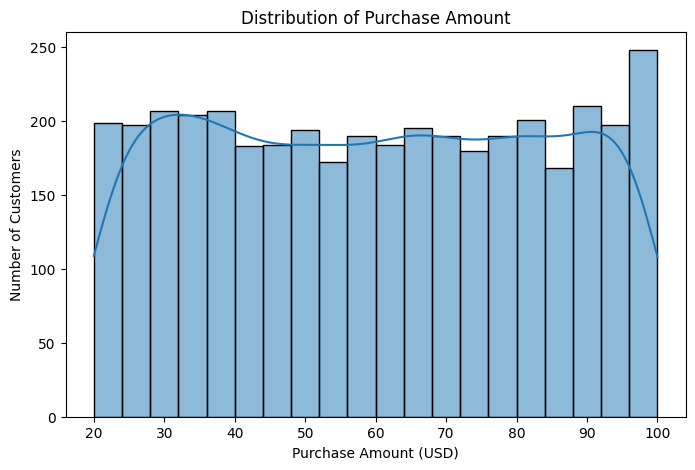

In [97]:
# Purchase Amount Distribution (generally how much the customers are spending)
plt.figure(figsize=(8,5))

sns.histplot(
    data = df,
    x = 'Purchase Amount (USD)',
    bins = 20,
    kde = True
)
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Number of Customers')

plt.show()
    


In [ ]:
# Insights
Purchase amounts are fairly evenly distributed across the range, with some higher concentration around $90–$100.”

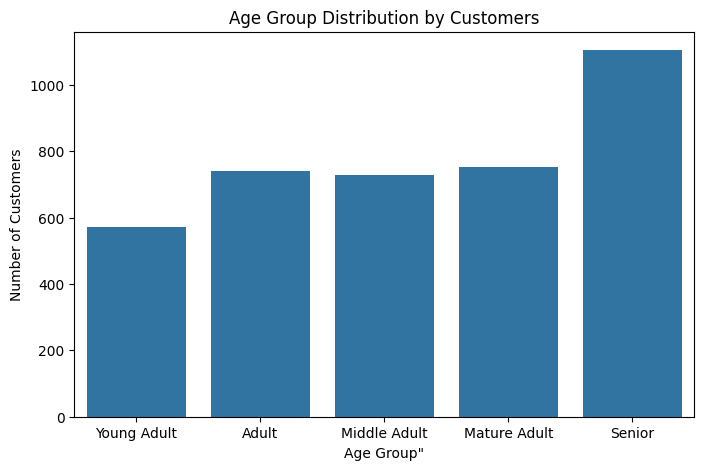

In [98]:
# Age Distribution

plt.figure(figsize = (8,5))

sns.countplot(
    data = df,
    x = 'Age_Group'
)
plt.title('Age Group Distribution by Customers')
plt.xlabel('Age Group"')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
# Insights
“Senior customers are the largest age group in the dataset, while Young Adults are the smallest.
so the customer base is more concentrated among older customers.”

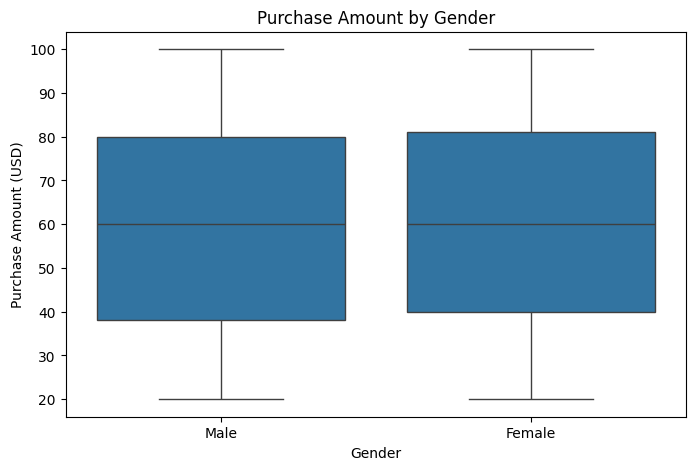

In [99]:
# Gender vs Purchase Amount
plt.figure(figsize = (8,5))

sns.boxplot(
    data = df,
    x = 'Gender',
    y = 'Purchase Amount (USD)'
    
)

plt.title("Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Purchase Amount (USD)")

plt.show()

In [ ]:
# Insights
Purchase behavior appears quite similar between Male and Female customers, with nearly the same median purchase amount. 
Female customers show slightly more variation in their purchase amounts

In [101]:
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Purchase_Segment,Age_Group,Purchase_Frequency_Annual,Estimated_Annual_Spend
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Express,Yes,Yes,14,Venmo,Bi-Weekly,Medium,Mature Adult,26,1378
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Express,Yes,Yes,2,Cash,Bi-Weekly,Medium,Young Adult,26,1664
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Medium,Mature Adult,52,3796
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Next Day Air,Yes,Yes,49,PayPal,Weekly,High,Young Adult,52,4680
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Free Shipping,Yes,Yes,31,PayPal,Annually,Medium,Middle Adult,1,49


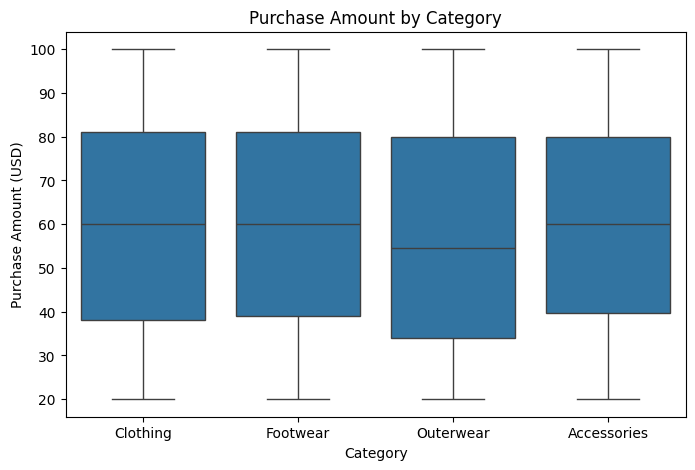

In [100]:
# Categories wise Purchase Amount
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Category",
    y="Purchase Amount (USD)"
)

plt.title("Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Purchase Amount (USD)")

plt.show()

In [ ]:
# Insights 
The purchase amount distribution for Clothing, 
Footwear and Accessories appears higher compared with Outerwear

In [102]:
df.groupby("Category")["Purchase Amount (USD)"].mean()

Category
Accessories    59.838710
Clothing       60.025331
Footwear       60.255426
Outerwear      57.172840
Name: Purchase Amount (USD), dtype: float64

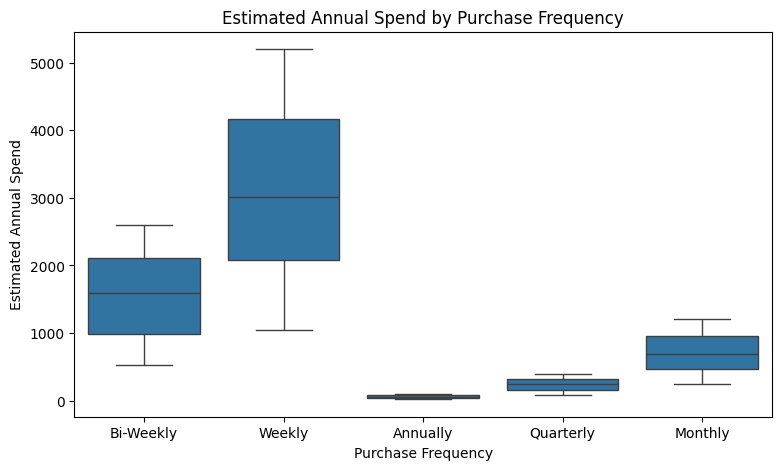

In [105]:
# Purchase Frequency vsEstimated_Annual_Spend
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="Frequency of Purchases",
    y="Estimated_Annual_Spend"
)

plt.title("Estimated Annual Spend by Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Estimated Annual Spend")

plt.show()

In [ ]:
# insights
Customers who purchase weekly have the highest estimated annual spend, 
while customers who purchase annually have the lowest

In [106]:
# Gender Percentage
gender_pct = (
    df["Gender"]
    .value_counts(normalize=True)
    .mul(100)
)

gender_pct

Gender
Male      68.0
Female    32.0
Name: proportion, dtype: float64

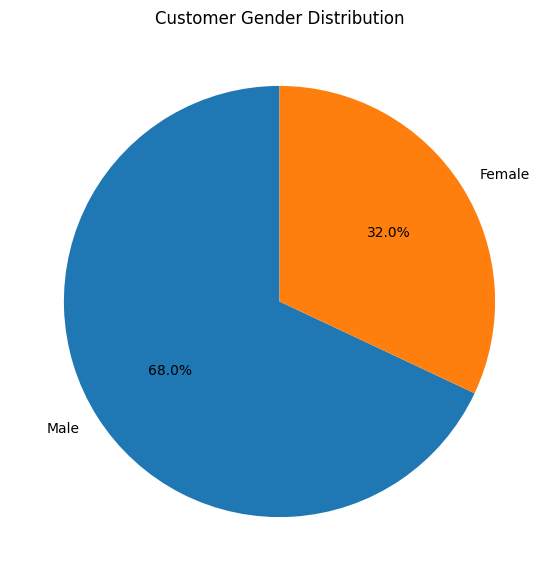

In [107]:
plt.figure(figsize=(7,7))

plt.pie(
    gender_pct,
    labels=gender_pct.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Gender Distribution")

plt.show()

In [ ]:
# insights
The dataset has a higher proportion of Male customers, 
with Male customers representing 68% compared to 32% Female customers.”

In [108]:
# Discount Usage
discount_pct = (
    df["Discount Applied"]
    .value_counts(normalize=True)
    .mul(100)
)

discount_pct

Discount Applied
No     57.0
Yes    43.0
Name: proportion, dtype: float64

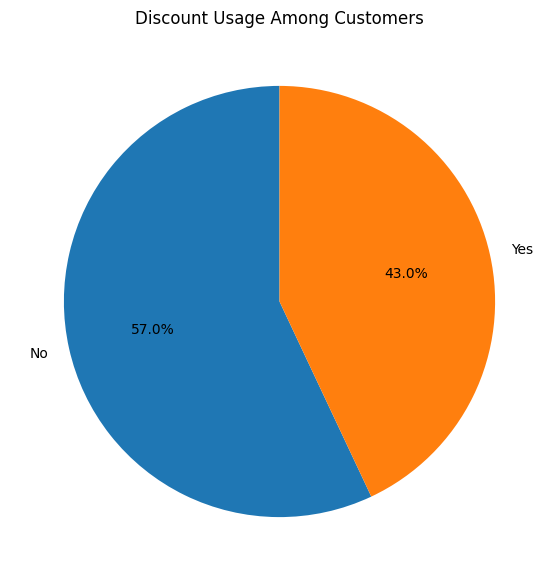

In [111]:
plt.figure(figsize=(7,7))

plt.pie(
    discount_pct,
    labels=discount_pct.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Discount Usage Among Customers")

plt.show()

In [ ]:
# insights
57% of customers did not receive a discount, while 43% received a discount

In [113]:
df["Rating_Group"] = pd.cut(
    df["Review Rating"],
    bins=[2.4, 3.0, 3.5, 4.0, 4.5, 5.0],
    labels=["2.5-3.0", "3.0-3.5", "3.5-4.0", "4.0-4.5", "4.5-5.0"]
)

In [114]:
df.groupby("Rating_Group")["Purchase Amount (USD)"].mean()

C:\Users\Namrata\AppData\Local\Temp\ipykernel_13488\1243807573.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Rating_Group")["Purchase Amount (USD)"].mean()


Rating_Group
2.5-3.0    58.940968
3.0-3.5    59.528160
3.5-4.0    59.054362
4.0-4.5    60.524246
4.5-5.0    61.004286
Name: Purchase Amount (USD), dtype: float64

In [116]:
rating_purchase = (
    df.groupby("Rating_Group", observed=True)["Purchase Amount (USD)"]
      .mean()
      .reset_index()
)


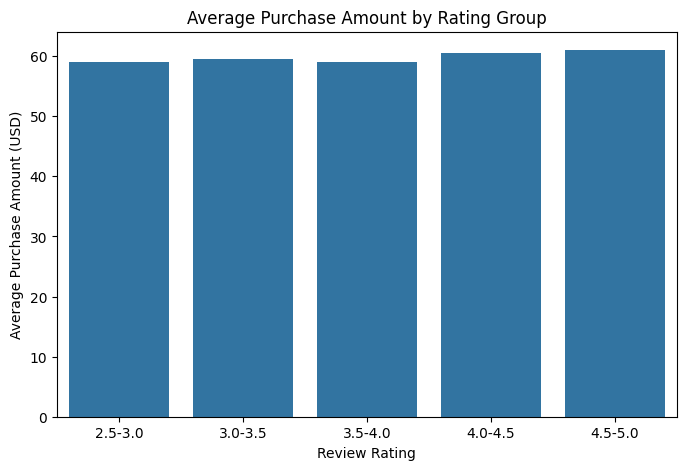

In [117]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rating_purchase,
    x="Rating_Group",
    y="Purchase Amount (USD)"
)

plt.title("Average Purchase Amount by Rating Group")
plt.xlabel("Review Rating")
plt.ylabel("Average Purchase Amount (USD)")

plt.show()

In [118]:
# Payment Method 
df["Payment Method"].value_counts()

Payment Method
Credit Card      696
Venmo            653
Cash             648
PayPal           638
Debit Card       633
Bank Transfer    632
Name: count, dtype: int64

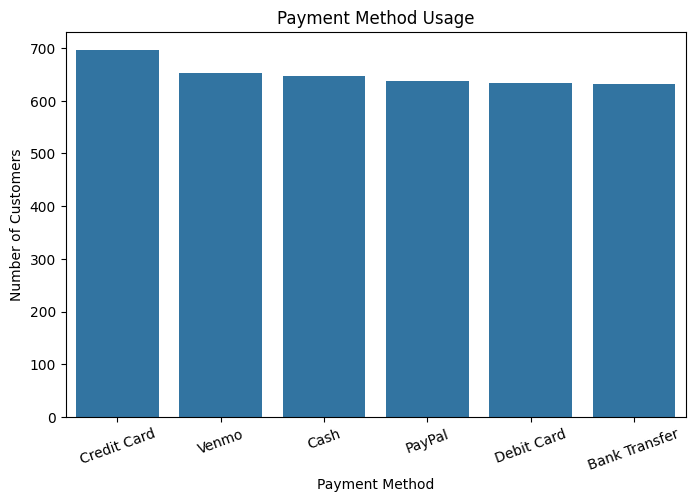

In [119]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Payment Method",
    order=df["Payment Method"].value_counts().index
)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

In [ ]:
# insights
“Credit Card is the most commonly used payment method, 
with 696 customers. Bank Transfer is the least used, with 632 customers

In [120]:
# Discount vs Purchase Amount
df.groupby("Discount Applied")["Purchase Amount (USD)"].mean()

Discount Applied
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64

In [121]:
discount_purchase = (
    df.groupby("Discount Applied")["Purchase Amount (USD)"]
      .mean()
      .reset_index()
)

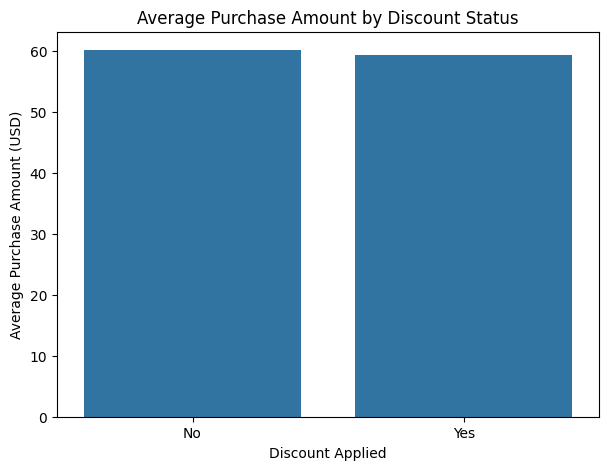

In [122]:

plt.figure(figsize=(7,5))

sns.barplot(
    data=discount_purchase,
    x="Discount Applied",
    y="Purchase Amount (USD)"
)

plt.title("Average Purchase Amount by Discount Status")
plt.xlabel("Discount Applied")
plt.ylabel("Average Purchase Amount (USD)")

plt.show()

In [ ]:
# insights
Customers without a discount have a higher average purchase amount than customers with a discount.

In [123]:
# Previous Purchases vs Customer Value
df["Previous_Purchase_Group"] = pd.cut(
    df["Previous Purchases"],
    bins=[0, 10, 20, 30, 40, 50],
    labels=["1-10", "11-20", "21-30", "31-40", "41-50"]
)

In [127]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Purchase_Segment,Age_Group,Purchase_Frequency_Annual,Estimated_Annual_Spend,Rating_Group,Previous_Purchase_Group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,14,Venmo,Bi-Weekly,Medium,Mature Adult,26,1378,3.0-3.5,11-20
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,2,Cash,Bi-Weekly,Medium,Young Adult,26,1664,3.0-3.5,1-10
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,23,Credit Card,Weekly,Medium,Mature Adult,52,3796,3.0-3.5,21-30
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,49,PayPal,Weekly,High,Young Adult,52,4680,3.0-3.5,41-50
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,31,PayPal,Annually,Medium,Middle Adult,1,49,2.5-3.0,31-40


In [124]:
df.groupby(
    "Previous_Purchase_Group",
    observed=True
)["Estimated_Annual_Spend"].mean()

Previous_Purchase_Group
1-10     1041.540816
11-20    1022.038610
21-30    1028.197468
31-40    1051.332908
41-50    1051.785621
Name: Estimated_Annual_Spend, dtype: float64

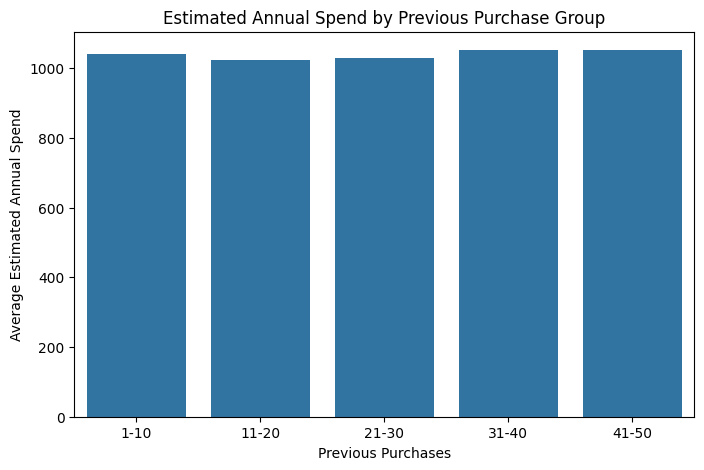

In [125]:
previous_purchase_spend = (
    df.groupby(
        "Previous_Purchase_Group",
        observed=True
    )["Estimated_Annual_Spend"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=previous_purchase_spend,
    x="Previous_Purchase_Group",
    y="Estimated_Annual_Spend"
)

plt.title("Estimated Annual Spend by Previous Purchase Group")
plt.xlabel("Previous Purchases")
plt.ylabel("Average Estimated Annual Spend")

plt.show()

In [ ]:
# insights
The average estimated annual spend is quite similar across all previous-purchase groups. 
The 31–40 and 41–50 groups have the highest average, while the 11–20 group has the lowest.

In [130]:
# deciding customer value 
# checking distribution
df["Estimated_Annual_Spend"].describe()

count    3900.000000
mean     1038.930513
std      1145.034309
min        20.000000
25%       188.000000
50%       572.000000
75%      1638.000000
max      5200.000000
Name: Estimated_Annual_Spend, dtype: float64

In [131]:
# need to create segmentation column 
df["Customer_Value_Segment"] = pd.cut(
    df["Estimated_Annual_Spend"],
    bins=[-1, 188, 572, 1638, float("inf")],
    labels=["Low Value", "Medium-Low Value", "Medium-High Value", "High Value"]
)

In [132]:
df["Customer_Value_Segment"].value_counts()

Customer_Value_Segment
Low Value            981
Medium-Low Value     978
High Value           972
Medium-High Value    969
Name: count, dtype: int64

In [133]:
# Analyzing segments
df.groupby("Customer_Value_Segment")[
    ["Purchase Amount (USD)", "Previous Purchases", "Purchase_Frequency_Annual"]
].mean()

C:\Users\Namrata\AppData\Local\Temp\ipykernel_13488\2949411524.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Customer_Value_Segment")[


,Purchase Amount (USD),Previous Purchases,Purchase_Frequency_Annual
Customer_Value_Segment,,,
Low Value,48.858308,24.891947,2.250765
Medium-Low Value,64.404908,26.186094,6.550102
Medium-High Value,52.056760,24.664603,23.112487
High Value,73.786008,25.660494,38.197531


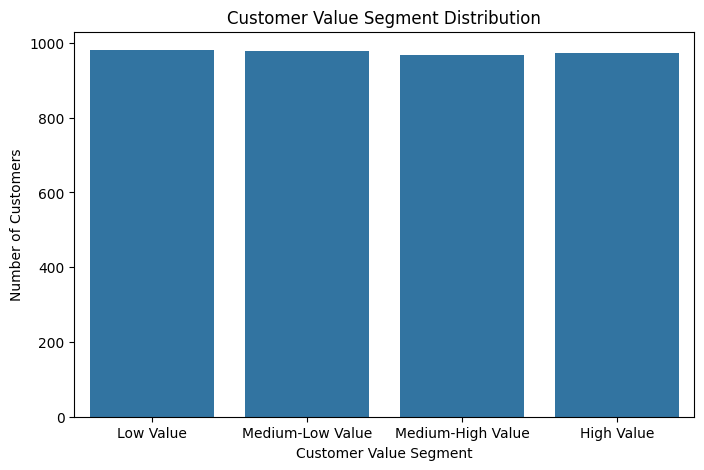

In [134]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Customer_Value_Segment",
    order=["Low Value", "Medium-Low Value", "Medium-High Value", "High Value"]
)

plt.title("Customer Value Segment Distribution")
plt.xlabel("Customer Value Segment")
plt.ylabel("Number of Customers")

plt.show()

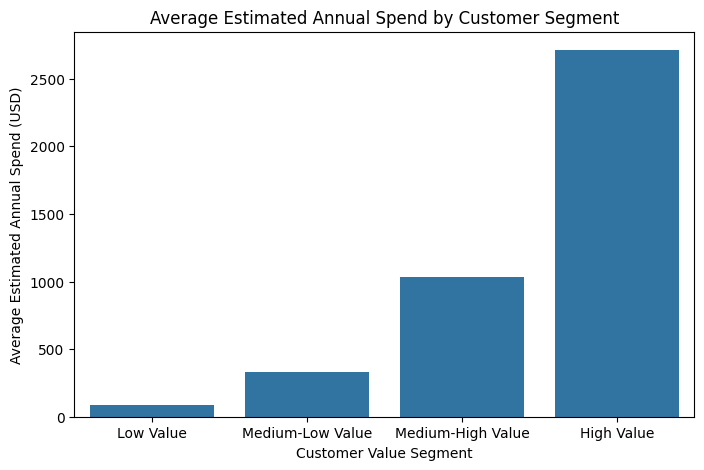

In [135]:
# Segment vs Estimated Annual Spend
segment_spend = (
    df.groupby("Customer_Value_Segment", observed=True)["Estimated_Annual_Spend"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_spend,
    x="Customer_Value_Segment",
    y="Estimated_Annual_Spend"
)

plt.title("Average Estimated Annual Spend by Customer Segment")
plt.xlabel("Customer Value Segment")
plt.ylabel("Average Estimated Annual Spend (USD)")

plt.show()

In [ ]:
# insights
wanted to see how the annual spending is different across the four customer groups.